In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-05-01 09:07:40,642::INFO::settings.py::Setting loglevel to INFO
2025-05-01 09:07:40,643::INFO::settings.py::Setting stores to {}
2025-05-01 09:07:40,644::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-05-01 09:07:40,645::INFO::settings.py::Setting database.misc.create_tables to True
2025-05-01 09:07:40,646::INFO::settings.py::Setting enable_python_native_blobs to True
2025-05-01 09:07:40,647::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-05-01 09:07:40,648::INFO::settings.py::Setting database.user to thomas
2025-05-01 09:07:40,648::INFO::settings.py::Setting database.password to thomas_mathislab
2025-05-01 09:07:40,840::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-05-01 09:07:40,949::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:41,382::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:41,382::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:41,871::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:41,871::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,027::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,027::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,372::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,372::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,708::INFO::table.py::could not log event in table ~log
2025-05-01 09:07:42,708::INFO::table.py::could not log event in table ~log


In [36]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.schema.vr4mice import Dataset

from statsmodels.stats.anova import AnovaRM
import scipy.stats as stats
from scipy.stats import ttest_rel


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
tolias = pd.read_pickle("big_df_contrast_tolias_new.pkl")
neil_df = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis =  pd.read_pickle("dual_occluder.pickle")

big_df = pd.concat([tolias, neil_df, mathis]).reset_index(drop=True)
big_df, reward_table = utils.dual_occluder_inclusion_criteria(big_df, return_excluded=False)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=3).copy()
interpolated_j_shaped = utils.interpolate_j_shaped(
    j_shaped, box_df, n_points=100
)  # 100 to run anova
data = interpolated_j_shaped

Excluded datasets:  ['31728_2025-03-05_1' '31728_2025-03-06_1' 'J729_2024-11-29_1'
 'J731_2024-12-04_1' 'J731_2024-12-06_1']


In [6]:
def mean_trajectory_time(df, index_columns = ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"], values=["x", "y"]):
    
    mean_df = df.groupby(index_columns,as_index=False)[values].mean()
    mean_df [["sem_x", "sem_y"]] = df.groupby(index_columns,as_index=False)[values].sem()[values]
    return(mean_df)

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # For custom legend handles

def plot_mean_trajectory_time(df, cmap=["red", "blue"], color_by="choice", style_by="aperture"):
    """
    Plots mean trajectories with flexible assignment of colors and line styles.
    
    Parameters:
    -----------
    df : DataFrame
        Contains columns: x, y, sem_x, sem_y, aperture, trial_left_choice
    cmap : list or matplotlib colormap
        Color scheme for different choices
    color_by : str ('choice' or 'aperture')
        Which variable to represent with colors
    style_by : str ('choice' or 'aperture')
        Which variable to represent with line styles
    """
    
    if color_by not in ['choice', 'aperture']:
        raise ValueError("color_by must be either 'choice' or 'aperture'")
    if style_by not in ['choice', 'aperture']:
        raise ValueError("style_by must be either 'choice' or 'aperture'")
    if color_by == style_by:
        raise ValueError("color_by and style_by must represent different variables")
    

    choices = df.trial_left_choice.unique()
    apertures = df.aperture.unique()
    
   
    if color_by == 'choice':
        color_var = 'trial_left_choice'
        color_values = choices
    else:
        color_var = 'aperture'
        color_values = apertures
    
    if isinstance(cmap, list):
        if len(cmap) < len(color_values):
            raise ValueError(f"Need at least {len(color_values)} colors, got {len(cmap)}")
        colors = {val: cmap[i] for i, val in enumerate(color_values)}
    else:
        colors = {val: cmap(i/(len(color_values)-1)) for i, val in enumerate(color_values)}
    
   
    if style_by == 'choice':
        style_var = 'trial_left_choice'
        style_values = choices
    else:
        style_var = 'aperture'
        style_values = apertures
    
    line_styles = ['-', '--', ':', '-.']
    styles = {val: line_styles[i % len(line_styles)] 
              for i, val in enumerate(style_values)}
    
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    group_vars = [color_var, style_var]
    for (color_val, style_val), data in df.groupby(group_vars):
        color = colors[color_val]
        style = styles[style_val]
        label = f"{color_var.capitalize()} {color_val} | {style_var.capitalize()} {style_val}"
        
        # Main trajectory
        ax.plot(data.x, data.y, color=color, linestyle=style, label=label, linewidth=2)
        
        # Error bands
        alpha = 0.15
        ax.fill_betweenx(data.y, data.x-data.sem_x, data.x+data.sem_x,
                        color=color, alpha=alpha)
        ax.fill_between(data.x, data.y-data.sem_y, data.y+data.sem_y,
                       color=color, alpha=alpha)
    
    
    legend_elements = []
   
    for val in color_values:
        legend_elements.append(Line2D([0], [0], color=colors[val], lw=4,
                                    label=f'{color_var.capitalize()} {val}'))
    for val in style_values:
        legend_elements.append(Line2D([0], [0], color='black', linestyle=styles[val],
                                    lw=2, label=f'{style_var.capitalize()} {val}'))
    
    ax.legend(handles=legend_elements, loc='lower right')
    ax.grid(False)
    ax.set_xlim(-18,18)
    ax.set_ylim(0,23)
    ax.vlines(x=-15, ymin=2, ymax=7, color="black", linewidth=2)
    ax.hlines(y=2, xmin=-15, xmax=-5, color="black", linewidth=2)
    plt.axis("off")
    
    return fig, ax

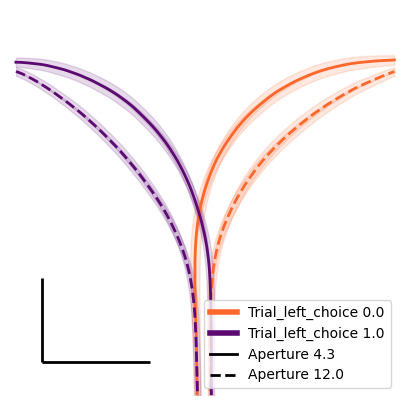

In [8]:
dfp = mean_trajectory_time(data, index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
dfp = mean_trajectory_time(dfp, index_columns= ["aperture",  "trial_left_choice", "trial_length"])
plot_mean_trajectory_time(dfp, cmap = plotting.colors_choice [::-1],color_by="choice", style_by="aperture")
plt.savefig("dual_occluder_mean_trajectories_all_labs.svg", transparent=True)

In [9]:
data["flip_one_side"] = data["trial_left_choice"].replace([0, 1], [1, -1])
data["x_flipped"] = data.x * data.flip_one_side
data = utils.create_bins(data)

In [10]:
dfp = mean_trajectory_time(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])


Text(0, 0.5, 'X position')

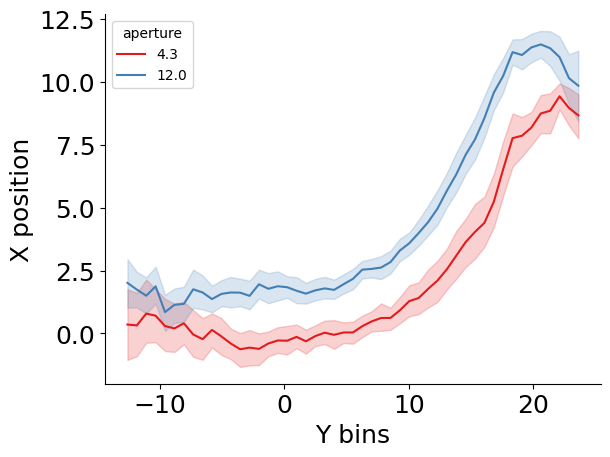

In [11]:
sns.lineplot(data = dfp, x="bin_centers", y="x_flipped", hue="aperture", palette= plotting.colors_aperture)
plt.xlabel("Y bins")
plt.ylabel("X position")

In [15]:
dfp = dfp [(dfp.bin_centers > -10) & (dfp.bin_centers < 18)]
print(
    AnovaRM(
        data=dfp,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                        Anova
                     F Value   Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              67.3207  1.0000   42.0000 0.0000
bin_centers          116.1695 36.0000 1512.0000 0.0000
aperture:bin_centers   9.3050 36.0000 1512.0000 0.0000



In [17]:
p_values = []
for i in dfp.bin_centers.unique():
    section = dfp [dfp.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

Text(0, 0.5, 'Corrected p-values')

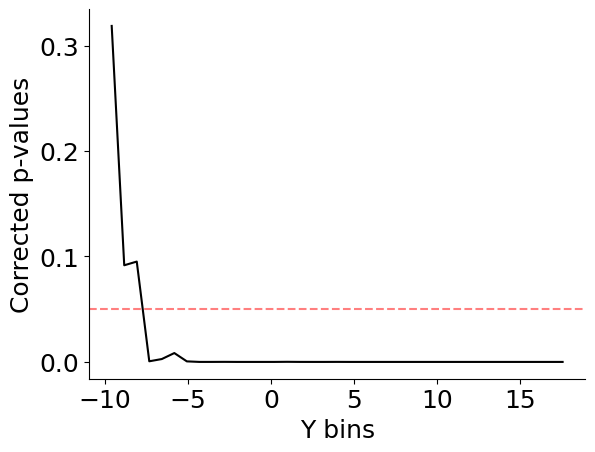

In [28]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("Corrected p-values")

# plot dual occluders for single mouse

(<Figure size 500x500 with 1 Axes>, <Axes: >)

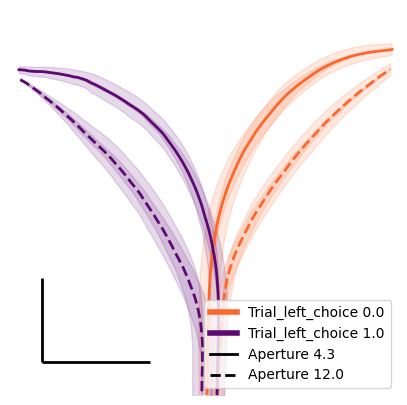

In [9]:
# get mean trajectories for each session of mouse
dfp = mean_trajectory_time(data [data.mouse_name == data.mouse_name.unique()[7]],
                                               index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
# mean across sessions to get mouse mean and sem
dfp = mean_trajectory_time(dfp, index_columns= [ "mouse_name", "aperture", "trial_left_choice", "trial_length"])
plot_mean_trajectory_time(dfp, cmap = plotting.colors_choice[::-1])

Pheasant_2024-08-16_1


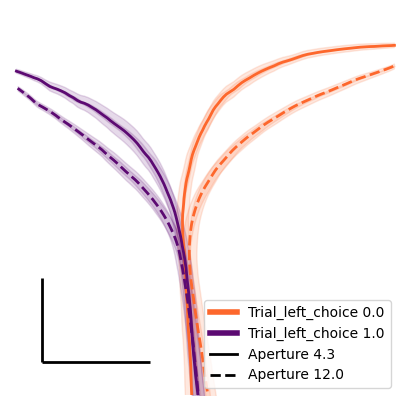

In [10]:
# get mean trajectories for each session of mouse
d = data.dataset.unique()[-3]
print(d)
dfp = mean_trajectory_time(data [data.dataset == d],
                                               index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
# mean across sessions to get mouse mean and sem
#dfp = mean_trajectory_time(dfp, index_columns= [ "dataset", "aperture", "trial_left_choice", "trial_length"])
plot_mean_trajectory_time(dfp, cmap = plotting.colors_choice[::-1])
plt.savefig(f"{d}_mean_trajectories.svg", transparent=True)

In [13]:
#big_df = pd.read_pickle("notebooks/Paper_figures/multi_occluder.pickle")
big_df = pd.read_pickle("mutli_occluder_all_labs.pkl")
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=5).copy()
interpolated_j_shaped = utils.interpolate_j_shaped(
    j_shaped, box_df, n_points=100
)  # 100 to run anova
data = interpolated_j_shaped

In [14]:
big_df = pd.read_pickle("mutli_occluder_all_labs.pkl")
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
big_df, reward_table = utils.multi_occluder_inclusion_criteria(big_df, threshold_wide=.70, threshold_drop=.3, return_excluded=False)
big_df = big_df [(big_df.iti == 0.0) & (big_df.trial_rewarded > 0.5)].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=5).copy()
interpolated_j_shaped = utils.interpolate_j_shaped(
    j_shaped, box_df, n_points=100
)  # 100 to run anova
data = interpolated_j_shaped

Excluded datasets:  ['Pheasant_2024-08-23_1' 'Oribi_2024-08-23_1' '31728_2025-03-10_1'
 '31728_2025-03-17_1' '31726_2025-03-25_1']


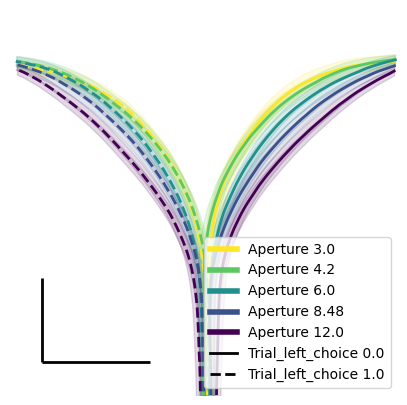

In [15]:
# get multioccluder mean across mice
dfp = mean_trajectory_time(data, index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
dfp = mean_trajectory_time(dfp, index_columns= ["aperture",  "trial_left_choice", "trial_length"])

plot_mean_trajectory_time(dfp, cmap = plt.cm.viridis_r, color_by="aperture", style_by="choice")
plt.savefig("multioccluder_trajectories_time.svg", transparent=True)

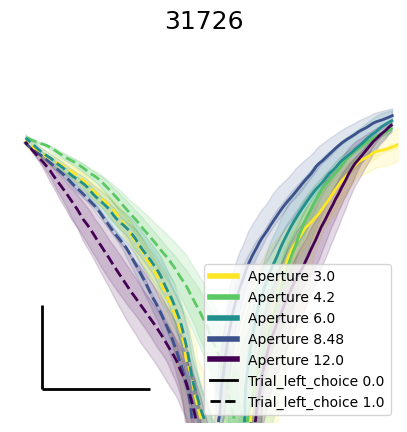

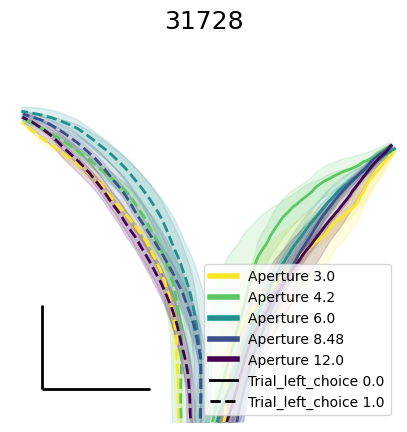

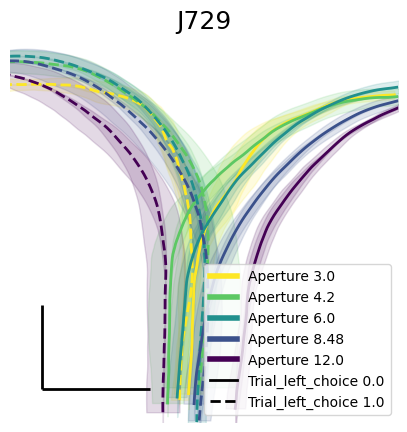

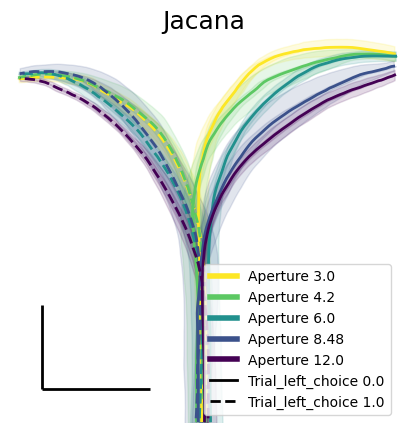

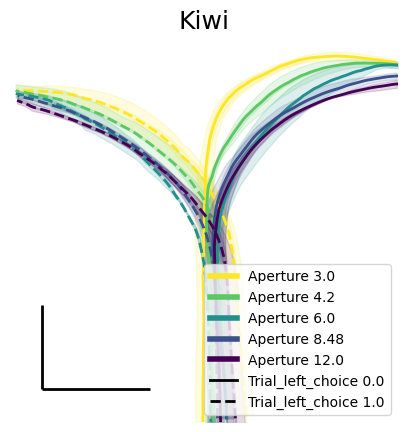

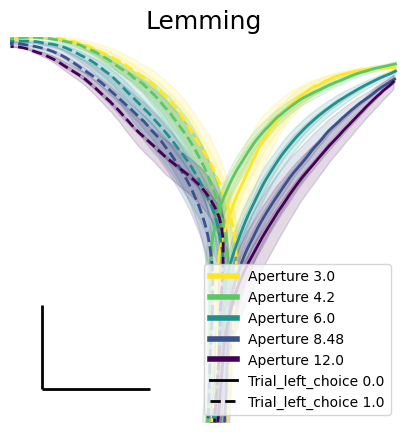

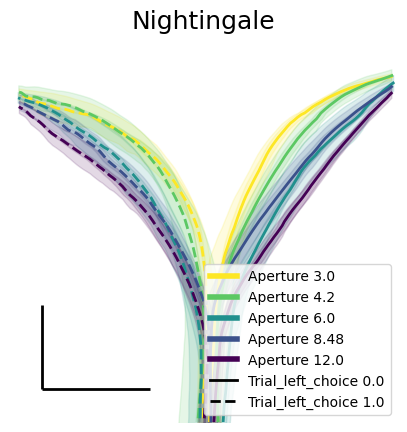

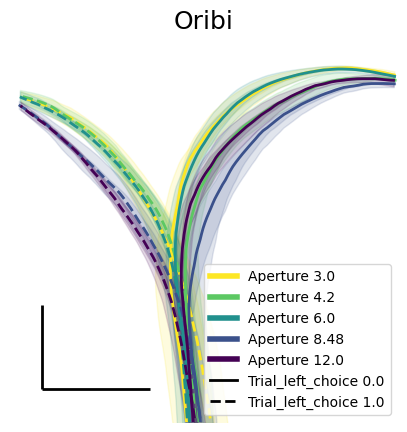

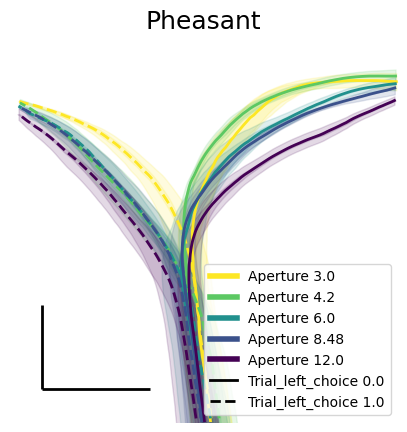

In [16]:
for m in data.mouse_name.unique():
    dfp = mean_trajectory_time(data [data.mouse_name == m],
                                                index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
    # mean across sessions to get mouse mean and sem
    dfp = mean_trajectory_time(dfp, index_columns= [ "mouse_name", "aperture", "trial_left_choice", "trial_length"])
    plot_mean_trajectory_time(dfp, cmap = plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(f"{m}")
    plt.savefig(f"multioccluder_trajectories_{m}.svg", transparent=True)

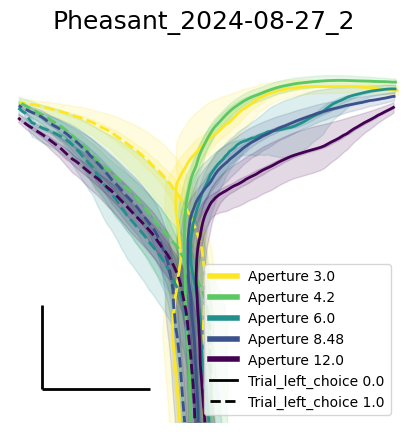

In [18]:
dfp = mean_trajectory_time(data [data.dataset == "Pheasant_2024-08-27_2"],
                                            index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
# mean across sessions to get mouse mean and sem
#dfp = mean_trajectory_time(dfp, index_columns= [ "dataset", "aperture", "trial_left_choice", "trial_length"])
plot_mean_trajectory_time(dfp, cmap = plt.cm.viridis_r, color_by="aperture", style_by="choice")
plt.title(f"Pheasant_2024-08-27_2")
plt.savefig("Pheasant_2024-08-27_2_mean_traj.svg", transparent = True)

In [52]:

data = utils.create_bins(data)

In [53]:
data["flip_one_side"] = data["trial_left_choice"].replace([0, 1], [1, -1])
data["x_flipped"] = data.x * data.flip_one_side
mean_mouse = (
    data.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)
mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

Text(0, 0.5, 'X position')

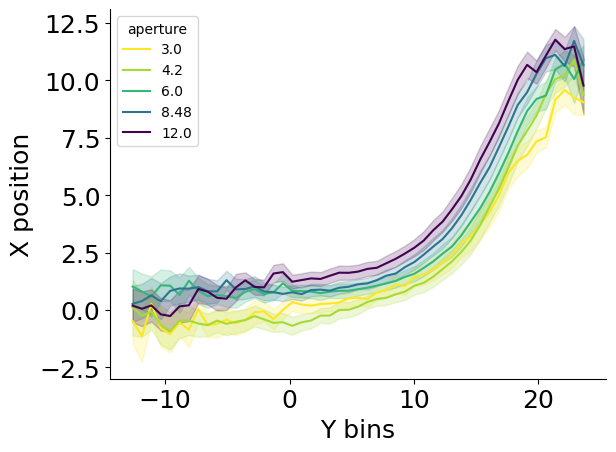

In [54]:
sns.lineplot(data = mean_mouse, x="bin_centers", y="x_flipped", hue="aperture", palette= plt.cm.viridis_r, errorbar="se")
plt.xlabel("Y bins")
plt.ylabel("X position")

In [56]:
mean_mouse = mean_mouse [(mean_mouse.bin_centers > -2) & (mean_mouse.bin_centers < 19)]
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              12.4401   4.0000  120.0000 0.0000
bin_centers          140.2546  26.0000  780.0000 0.0000
aperture:bin_centers   5.5709 104.0000 3120.0000 0.0000



In [57]:
import itertools
p_values = []
for bin_val in mean_mouse['bin_centers'].unique():
    bin_data = mean_mouse[mean_mouse['bin_centers'] == bin_val]
    apertures = bin_data['aperture'].unique()
    
    # Get all unique pairs of apertures
    for ap1, ap2 in itertools.combinations(apertures, 2):
        ap1_data = bin_data[bin_data['aperture'] == ap1]['x_flipped']
        ap2_data = bin_data[bin_data['aperture'] == ap2]['x_flipped']
        
        t_stat, p_val = ttest_rel(ap1_data, ap2_data)
        #print(f"Bin {bin_val}: Aperture {ap1} vs {ap2} - t = {t_stat:.3f}, p = {p_val:.4f}")
        p_values.append(pd.DataFrame({
            "bin": bin_val,
            "aperture1": ap1,
            "aperture2": ap2,
            "p_value": p_val
        }, index=[0]))
        
p_value_df=pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)


<Axes: xlabel='bin', ylabel='p_value_corr'>

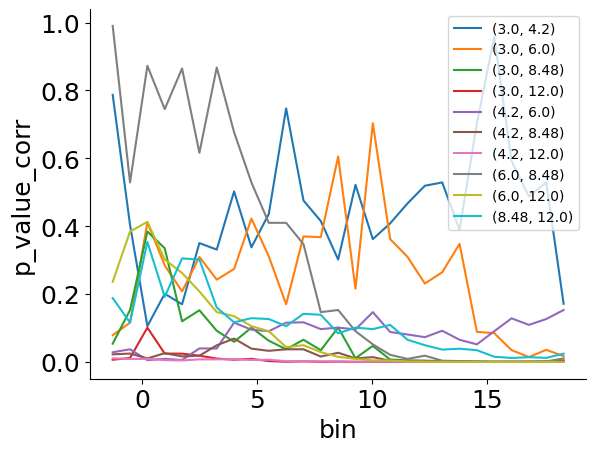

In [58]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))

In [62]:
p_value_df.pivot(index = "bin", columns=["aperture1", "aperture2"], values=["p_value_corr"])

p_value_corr                                                        \
aperture1         3.00                                        4.20             
aperture2        4.20      6.00      8.48          12.00     6.00      8.48    
bin                                                                            
-1.2955       0.786911  0.078723  0.053779  6.437536e-03  0.028427  0.022265   
-0.5405       0.403640  0.115677  0.152905  1.164035e-02  0.037224  0.024689   
 0.2145       0.105450  0.410905  0.384208  1.010242e-01  0.005282  0.010260   
 0.9695       0.200880  0.284564  0.334919  2.468897e-02  0.009037  0.025633   
 1.7245       0.169861  0.207791  0.119738  2.434137e-02  0.005732  0.016261   
 2.4795       0.350173  0.309435  0.152216  1.836398e-02  0.039642  0.018306   
 3.2345       0.330917  0.242415  0.091828  9.828765e-03  0.039642  0.048927   
 3.9895       0.502432  0.273934  0.059225  6.437536e-03  0.115677  0.068770   
 4.7445       0.337563  0.422299  0.101024  9.036869e-03  0.095009  0.039209   
 5.5000       0.435795  0.311109  0.062565  2.479187e-03  0.090453  0.032690   
 6.2555       0.746902  0.169861  0.037224  4.988005e-04  0.115677  0.037224   
 7.0105       0.475661  0.369642  0.065259  1.597553e-03  0.116711  0.037224   
 7.7655       0.414974  0.367777  0.034527  3.979114e-04  0.096656  0.015798   
 8.5205       0.301705  0.605365  0.101195  8.666379e-04  0.101195  0.027040   
 9.2755       0.521630  0.215789  0.010912  1.112982e-04  0.095762  0.010393   
 10.0305      0.361823  0.703326  0.047255  5.609476e-04  0.146730  0.014090   
 10.7855      0.408251  0.361823  0.006983  2.637029e-05  0.088181  0.003485   
 11.5405      0.466999  0.309435  0.004468  5.610176e-06  0.080880  0.003133   
 12.2955      0.519071  0.230970  0.003131  2.773080e-06  0.072916  0.003430   
 13.0510      0.528827  0.264121  0.002265  3.192114e-06  0.091828  0.001886   
 13.8065      0.389063  0.347814  0.002236  1.996673e-06  0.065259  0.000908   
 14.5615      0.703326  0.088471  0.000129  9.379949e-08  0.051742  0.000519   
 15.3165      0.957636  0.084803  0.000027  1.001939e-08  0.090453  0.000294   
 16.0715      0.592159  0.034704  0.000016  3.530481e-09  0.128406  0.000721   
 16.8265      0.487580  0.014484  0.000006  1.353892e-09  0.109159  0.000965   
 17.5815      0.528937  0.035590  0.000069  1.353892e-09  0.126432  0.001378   
 18.3365      0.171233  0.017066  0.000491  2.166320e-08  0.152905  0.004279   

                                                   
aperture1                6.00                8.48  
aperture2     12.00     8.48      12.00     12.00  
bin                                                
-1.2955    0.010620  0.989997  0.235890  0.188132  
-0.5405    0.008429  0.528827  0.384208  0.115677  
 0.2145    0.009009  0.872557  0.412582  0.353749  
 0.9695    0.005393  0.744892  0.301705  0.191895  
 1.7245    0.004279  0.864527  0.261999  0.304929  
 2.4795    0.007547  0.616110  0.207791  0.301705  
 3.2345    0.007547  0.867480  0.146730  0.160252  
 3.9895    0.008240  0.676831  0.134792  0.116711  
 4.7445    0.005691  0.528827  0.105450  0.128892  
 5.5000    0.006336  0.409804  0.090453  0.126432  
 6.2555    0.002161  0.409804  0.043596  0.105350  
 7.0105    0.002265  0.347072  0.049235  0.141738  
 7.7655    0.001706  0.146730  0.028826  0.138810  
 8.5205    0.001254  0.152905  0.014985  0.084417  
 9.2755    0.000684  0.090453  0.008938  0.101024  
 10.0305   0.000922  0.051742  0.004638  0.096656  
 10.7855   0.000627  0.020836  0.004279  0.109101  
 11.5405   0.000279  0.008938  0.001382  0.065259  
 12.2955   0.000241  0.018364  0.000865  0.049235  
 13.0510   0.000071  0.003485  0.000144  0.036341  
 13.8065   0.000025  0.002562  0.000097  0.038969  
 14.5615   0.000015  0.001523  0.000031  0.034527  
 15.3165   0.000004  0.000469  0.000004  0.015352  
 16.0715   0.000008  0.000530  0.000003  0.011640  
 16.8265   0.000003  0.000519  0.000002  0.013945  
 17.5815   0.000002  